In [1]:
import pandas as pd
import scanpy as sc
import seaborn as sns
import numpy as np
import scanpy as sc
from pathlib import Path
import matplotlib.pyplot as plt

Tutorial: https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html

In [2]:
adata = sc.read_10x_mtx(
    "/data/MERFISH/20241108_Bartelle_MouseMERFISH_LC/qi2labdatastore/mtx_output",  # the directory with the `.mtx` file
    var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
)
adata

AnnData object with n_obs × n_vars = 8560 × 135
    var: 'gene_ids', 'feature_types'

In [3]:
# Filter out cells with too few genes
sc.pp.filter_cells(adata, min_genes=5)
adata

AnnData object with n_obs × n_vars = 7226 × 135
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types'

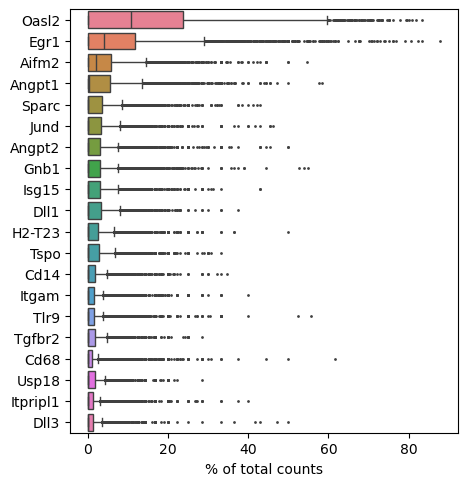

In [4]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [5]:
# Filter ourt genes that are detected in too few cells
sc.pp.filter_genes(adata, min_cells=5)
adata

AnnData object with n_obs × n_vars = 7226 × 135
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'n_cells'

In [6]:
sc.pp.calculate_qc_metrics(
    adata, percent_top=None, log1p=True, inplace=True
)

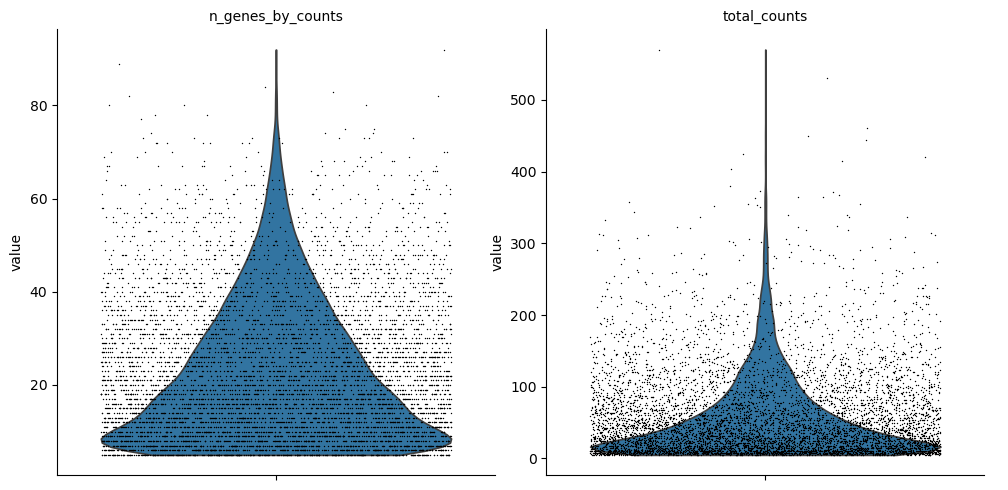

In [7]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts"],
    jitter=0.4,
    multi_panel=True,
)

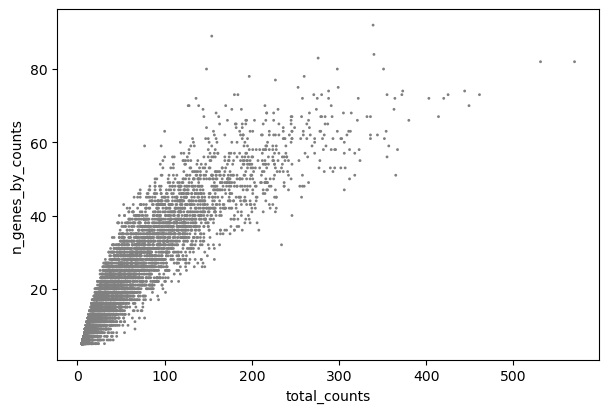

In [8]:
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

In [9]:
# Saving count data
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)

In [10]:
# Logarithmize the data
sc.pp.log1p(adata)

In [11]:
'''
Finding highly variable genes seems to affect the final results a lot!
'''
# sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
# sc.pl.highly_variable_genes(adata)

'\nFinding highly variable genes seems to affect the final results a lot!\n'

In [12]:
# sc.pp.highly_variable_genes(adata, n_top_genes=30)
sc.tl.pca(adata, n_comps=15)

In [13]:
sc.pp.neighbors(adata, n_neighbors=10, use_rep='X_pca')

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


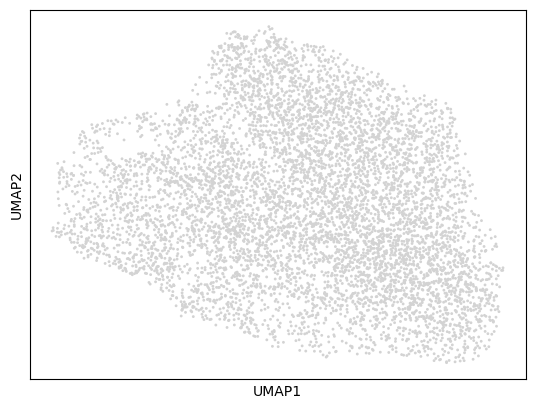

In [14]:
sc.tl.umap(adata)
sc.pl.umap(adata)

In [15]:
# Clustering the data
resolution_list = [0.1, 0.3, 0.5, 1.0]
for res in resolution_list:
    sc.tl.leiden(
        adata,
        resolution=res,
        flavor="igraph",
        n_iterations=2,
        key_added=f"leiden_res_{res:4.2f}"
        )

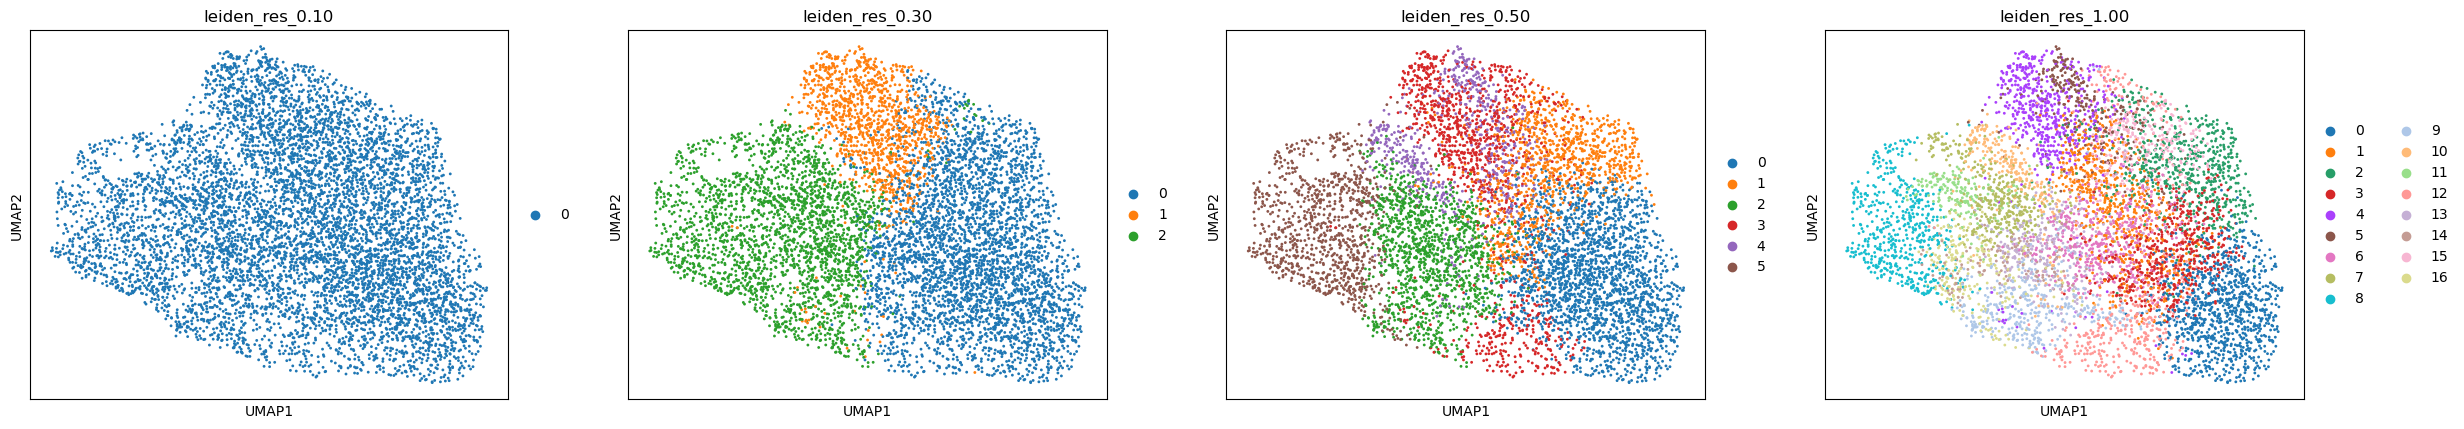

In [16]:
leiden_keys = [f"leiden_res_{res:4.2f}" for res in resolution_list]
sc.pl.umap(adata, color=leiden_keys)

## Modules

In [17]:
# Load modules dataframe
modules_df = pd.read_csv(
    "/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_combined_modules.csv",
    index_col=0)
modules_df.head()

,MG-Control-M1,MG-Control-M2,MG-Control-M3,MG-Control-M4,MG-Saline-M1,MG-Saline-M2,MG-Saline-M3,MG-LC-M1,MG-LC-M2,MG-LC-M3
0,Gfm2,Ifitm3,Tmsb4x,Bmp2k,Ifitm3,Gm11808,Ftl1,Cd52,Ftl1,Jun
1,Gm26917,Ifi204,Fth1,Bhlhe41,Ifit3,Gm8730,Gapdh,Ifi27l2a,Gapdh,Btg2
2,Gm8730,Oasl2,B2m,Notch2,Isg15,Gm2000,Fau,Cst7,Gm10076,Tmem119
3,Gm20721,Ifi27l2a,Eef1a1,Slc39a1,Ifi204,Gm10116,Cd63,Ifitm3,Uba52,Crybb1
4,Gm10116,Ifit3,Fau,Ptafr,Oasl2,Gm10073,Lag3,Irf7,Serf2,Slc2a5


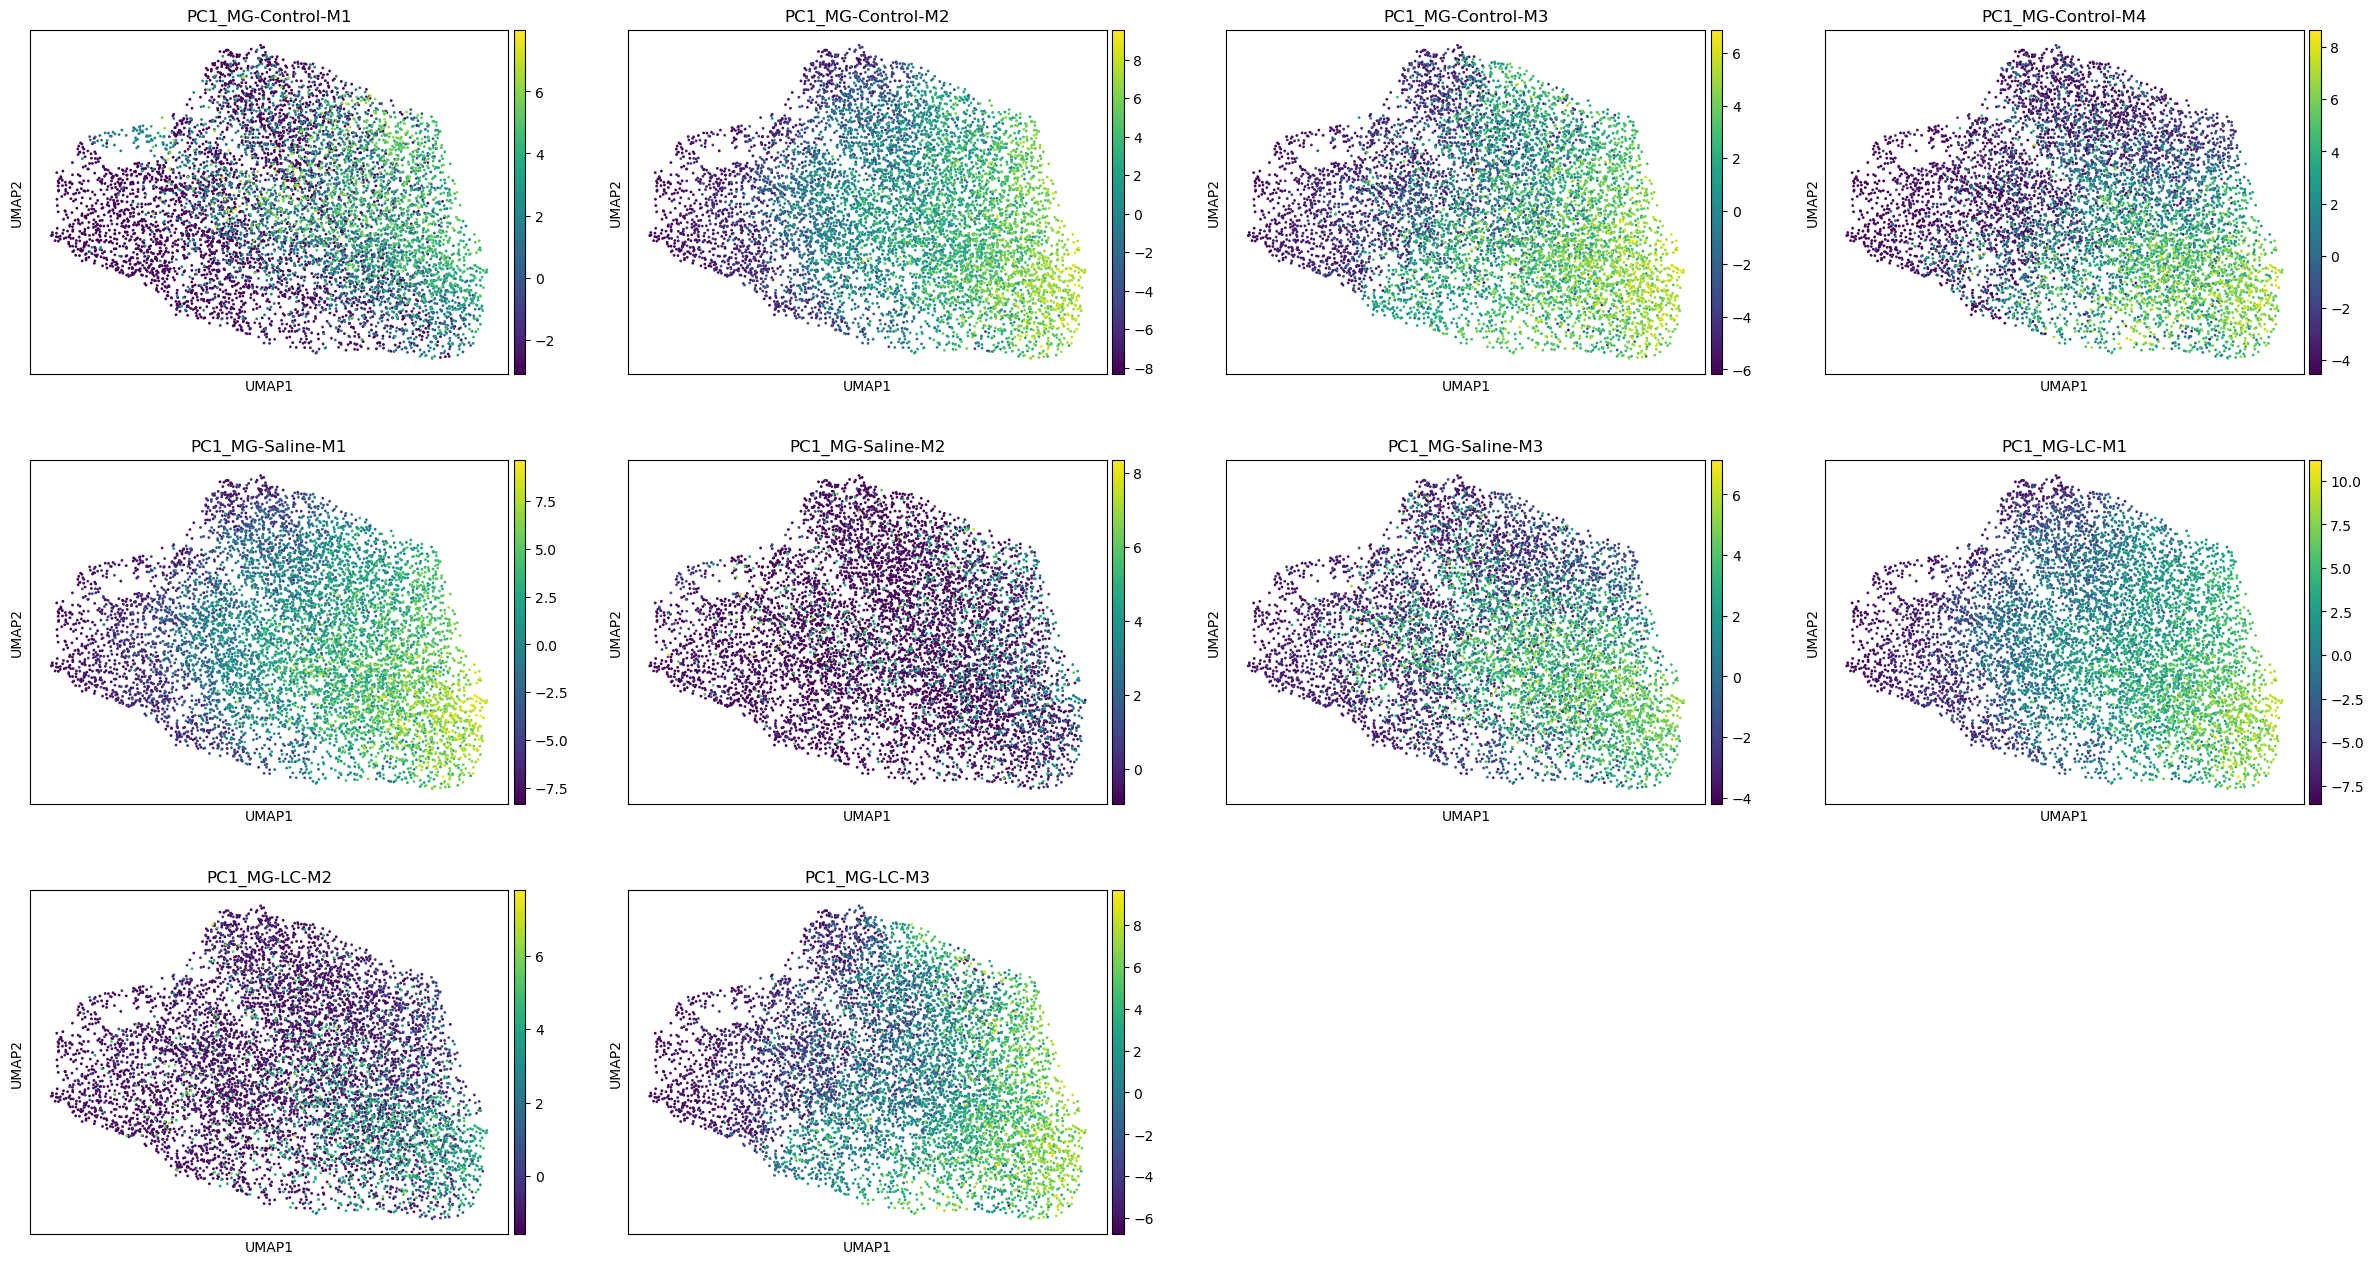

In [18]:
# Iterate over each module in the modules_df dataframe
for module_name in modules_df.columns:
    # Get the genes for the current module
    module_genes = modules_df[module_name].dropna().tolist()
    
    # Find the common genes between the module and the adata object
    common_genes = adata.var_names.intersection(module_genes)
    
    # Subset the adata object to include only the common genes
    adata_subset = adata[:, common_genes].copy()
    
    # Perform PCA on the subset
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]
    
    # Add the first principal component values to the adata object as a new observation
    adata.obs[f"PC1_{module_name}"] = pc1_values

# Visualize all modules together on UMAP
module_colors = [f"PC1_{module_name}" for module_name in modules_df.columns]
sc.pl.umap(adata, color=module_colors)

## Microglia markers

In [26]:
print(adata.var_names[:30])
print(adata.var_names[30:60])
print(adata.var_names[60:90])
print(adata.var_names[90:120])
print(adata.var_names[120:135])

Index(['Adgre1', 'Adrb2', 'Angpt1', 'Angpt2', 'Axl', 'Btg2', 'C5ar2', 'Calr',
       'Cd14', 'Cd44', 'Cd72', 'Clcf1', 'Cx3cr1', 'Cybb', 'Dcx', 'Ddit4',
       'Dll1', 'Dll3', 'Dpysl2', 'Egr1', 'Fcrls', 'Gnb1', 'Hspa1a', 'Icam1',
       'Ifi209', 'Ifit1', 'Ifit2', 'Ifit3', 'Ifit3b', 'Igf1'],
      dtype='object')
Index(['Irf7', 'Itgam', 'Itpripl1', 'Jag1', 'Jag2', 'Jun', 'Junb', 'Jund',
       'Lag3', 'Lgals3bp', 'Lpl', 'Lrba', 'Ly6e', 'Mog', 'Notch1', 'Notch2',
       'Notch3', 'Notch4', 'Oasl2', 'Olig1', 'P4hb', 'Pgk1', 'Picalm', 'Psap',
       'Ptafr', 'Ptprc', 'Rsad2', 'Serinc3', 'Serpina3n', 'Serpine2'],
      dtype='object')
Index(['Serping1', 'Slc10a6', 'Slc39a1', 'Slc7a8', 'Smad7', 'Sod2', 'Sox4',
       'Sparc', 'Stat1', 'Stat2', 'Stat3', 'Tek', 'Tgfbr2', 'Tlr2', 'Tlr4',
       'Tlr9', 'Tmem119', 'Tnf', 'Tsc22d3', 'Tulp3', 'Ucp2', 'Usp18', 'Vim',
       'Zfp36', 'Actb', 'Aif1', 'Aifm2', 'Apoe', 'Arg1', 'Bcl2a1b'],
      dtype='object')
Index(['Birc5', 'Bst2', 'Ccl3', 'Ccl4', 'C

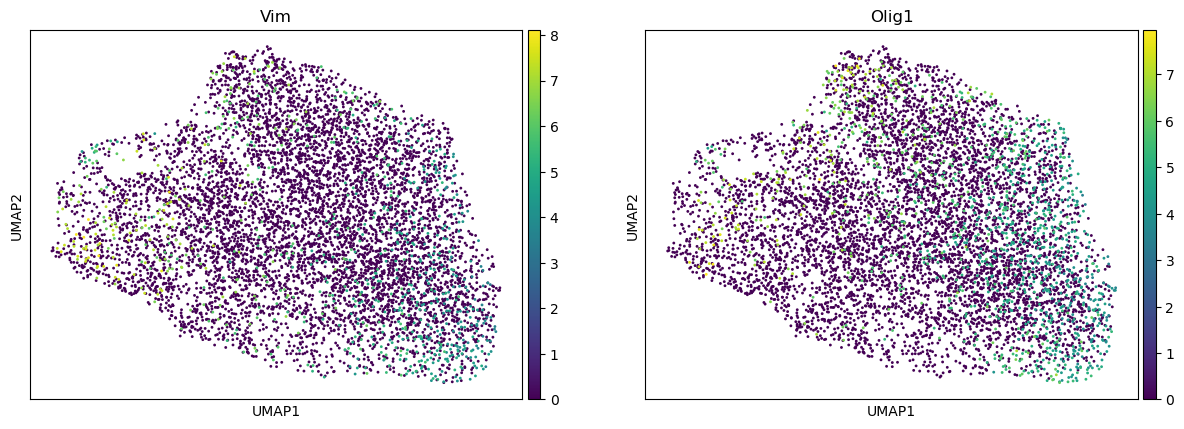

In [29]:
sc.pl.umap(adata, color=["Vim", "Olig1"])

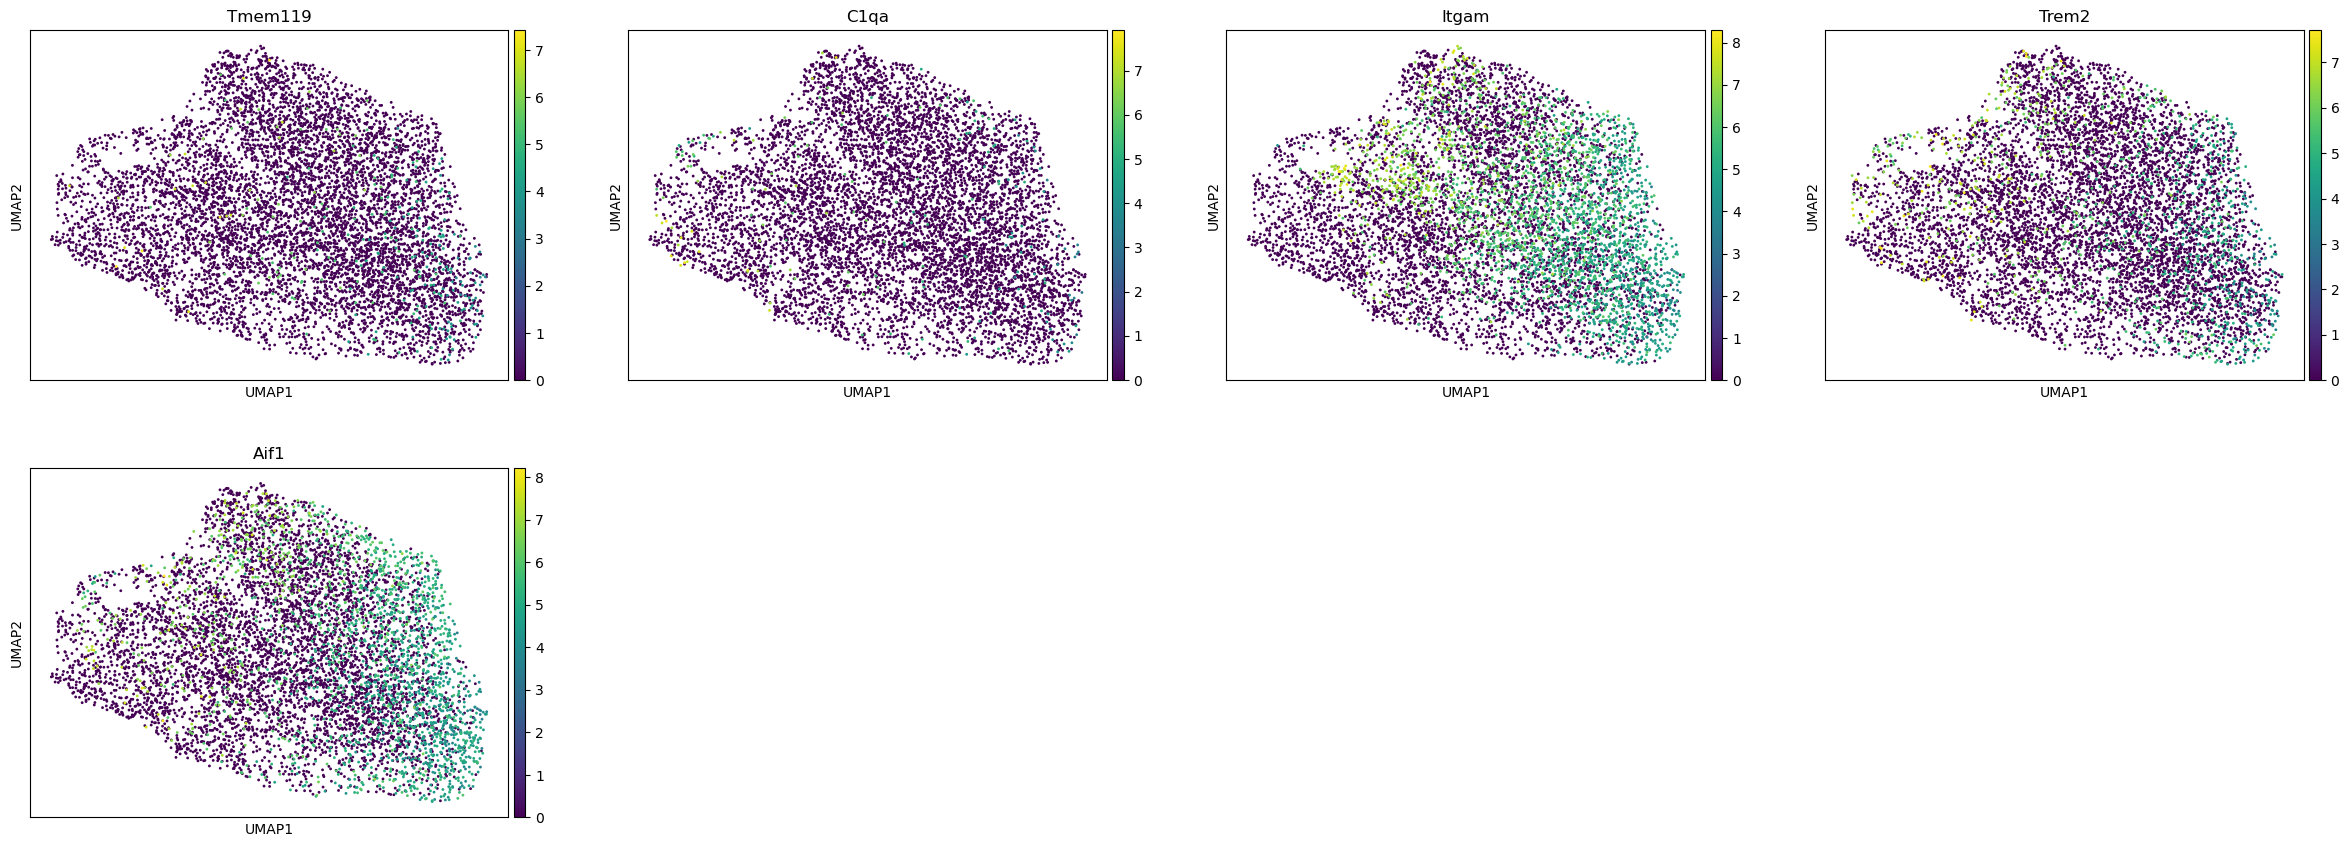

In [28]:
sc.pl.umap(adata, color=["Tmem119", "C1qa", "Itgam", "Trem2", "Aif1"])